# 11_model_comparison.ipynb

## Sprint 3 - PB-12: Comparación y selección de modelos baseline

Este notebook consolida los resultados del `10_evaluation.ipynb` para comparar los modelos baseline y seleccionar los mejores candidatos para el Sprint 4.

## Criterio de comparación

Para este caso, el objetivo es identificar empleados con riesgo de rotación. Por ello, se prioriza **Recall**, ya que interesa detectar la mayor cantidad posible de casos positivos.

Sin embargo, también se considera **F1-Score** y **AUC-ROC** para evitar seleccionar modelos que detecten muchos positivos pero con bajo equilibrio general.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [3]:
results = {
    "Modelo": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [0.5128, 0.8234, 0.9137, 0.7799, 0.7315],
    "Precision": [0.5125, 0.8132, 1.0000, 0.7478, 0.6533],
    "Recall": [0.5270, 0.8397, 0.8275, 0.8451, 0.9866],
    "F1": [0.5196, 0.8262, 0.9056, 0.7934, 0.7861],
    "AUC_ROC": [0.5232, 0.8234, 0.9662, 0.8585, 0.9038]
}

df_results = pd.DataFrame(results)
df_results

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,Logistic Regression,0.5128,0.5125,0.5270,0.5196,0.5232
1,Decision Tree,0.8234,0.8132,0.8397,0.8262,0.8234
2,Random Forest,0.9137,1.0000,0.8275,0.9056,0.9662
3,SVM,0.7799,0.7478,0.8451,0.7934,0.8585
4,KNN,0.7315,0.6533,0.9866,0.7861,0.9038


## Tabla comparativa

Se consolidan las métricas de los modelos baseline evaluados. Esta tabla permite comparar desempeño general, capacidad de detección y balance entre precision y recall.

In [4]:
df_ranked = df_results.sort_values(
    by=["Recall", "F1", "AUC_ROC"],
    ascending=False
).reset_index(drop=True)

df_ranked

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,KNN,0.7315,0.6533,0.9866,0.7861,0.9038
1,SVM,0.7799,0.7478,0.8451,0.7934,0.8585
2,Decision Tree,0.8234,0.8132,0.8397,0.8262,0.8234
3,Random Forest,0.9137,1.0000,0.8275,0.9056,0.9662
4,Logistic Regression,0.5128,0.5125,0.5270,0.5196,0.5232


## Visualización comparativa

El gráfico muestra el desempeño de cada modelo en las principales métricas. La leyenda se ubica fuera del área principal para facilitar la lectura.

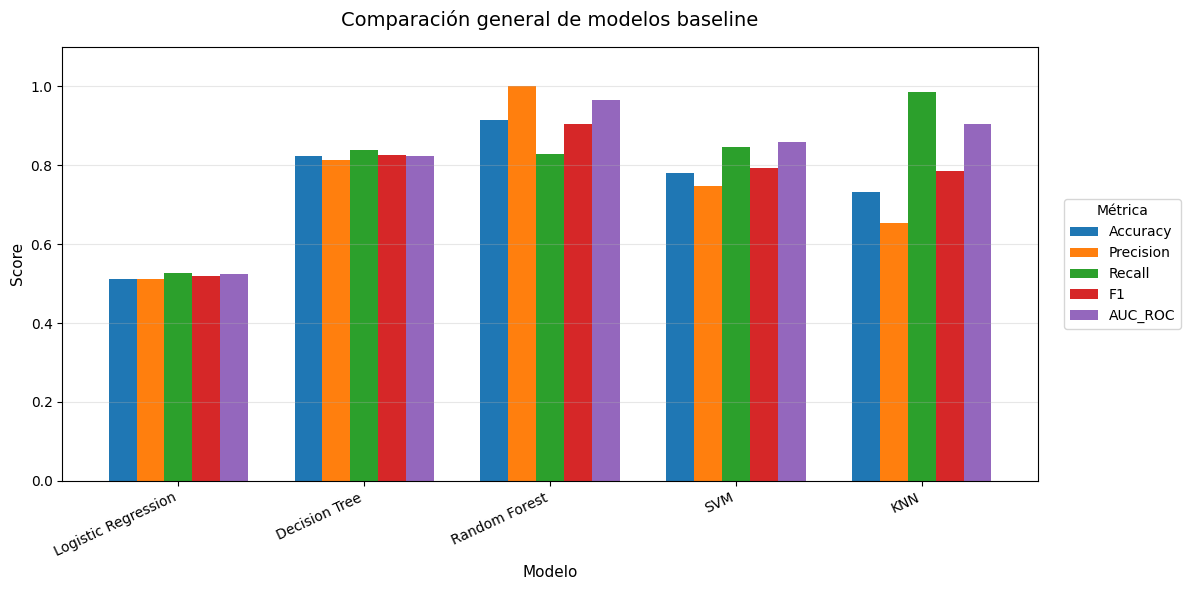

In [5]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC"]
df_plot = df_results.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1", "AUC_ROC"]]

ax = df_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

ax.set_title("Comparación general de modelos baseline", fontsize=14, pad=15)
ax.set_xlabel("Modelo", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.1)

ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

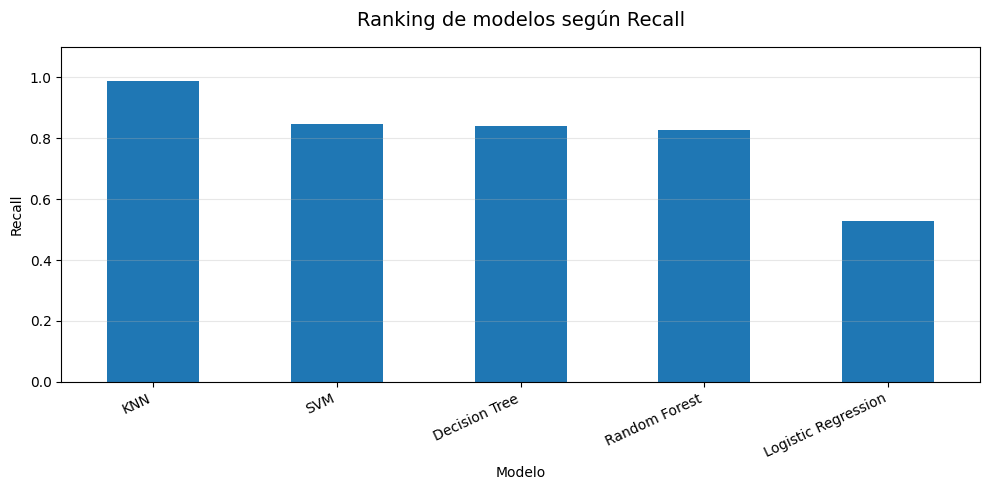

In [6]:
df_recall = df_results.sort_values("Recall", ascending=False)

ax = df_recall.plot(
    x="Modelo",
    y="Recall",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Ranking de modelos según Recall", fontsize=14, pad=15)
ax.set_ylabel("Recall")
ax.set_xlabel("Modelo")
ax.set_ylim(0, 1.1)

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Selección de candidatos

Aunque KNN obtiene el mayor Recall, Random Forest presenta el mejor balance general al combinar F1-Score alto, AUC-ROC alto y precisión perfecta.  
Por ello, se seleccionan tres candidatos para el Sprint 4 considerando tanto desempeño como utilidad para el negocio.

In [7]:
top_candidates = pd.DataFrame({
    "Modelo": ["KNN", "Random Forest"],
    "Motivo de selección": [
        "Mayor Recall; es el modelo que mejor detecta empleados en riesgo, alineado con la métrica principal del caso.",
        "Mejor balance general entre F1-Score, AUC-ROC y Precision; candidato sólido para tuning."
    ],
    "Rol para Sprint 4": [
        "Candidato principal si el negocio prioriza detección.",
        "Candidato complementario por desempeño global."
    ]
})

top_candidates

,Modelo,Motivo de selección,Rol para Sprint 4
0,KNN,"Mayor Recall; es el modelo que mejor detecta empleados en riesgo, alineado con la métrica principal del caso.",Candidato principal si el negocio prioriza detección.
1,Random Forest,"Mejor balance general entre F1-Score, AUC-ROC y Precision; candidato sólido para tuning.",Candidato complementario por desempeño global.


## Modelos descartados

Se descartan los modelos que no presentan suficiente competitividad frente a los candidatos seleccionados.

In [8]:
discarded_models = pd.DataFrame({
    "Modelo": ["Decision Tree", "Logistic Regression"],
    "Motivo de descarte": [
        "Aunque tiene buen desempeño, queda por debajo de Random Forest en F1-Score y AUC-ROC.",
        "Presenta los valores más bajos en F1-Score, AUC-ROC y Recall, por lo que no es competitivo."
    ]
})

discarded_models

,Modelo,Motivo de descarte
0,Decision Tree,"Aunque tiene buen desempeño, queda por debajo de Random Forest en F1-Score y AUC-ROC."
1,Logistic Regression,"Presenta los valores más bajos en F1-Score, AUC-ROC y Recall, por lo que no es competitivo."


## Trade-offs identificados

- **Random Forest** es el mejor candidato general por su equilibrio entre F1-Score, AUC-ROC y Precision.
- **KNN** destaca por Recall, por lo que es útil si el negocio prioriza detectar la mayor cantidad de empleados en riesgo.
- **SVM** ofrece un desempeño competitivo y puede ser útil como alternativa en el Sprint 4.
- **Decision Tree** es interpretable, pero queda por debajo de Random Forest.
- **Logistic Regression** funciona como baseline simple, pero no muestra desempeño suficiente para pasar a tuning.

## Observación metodológica

La comparación se realiza con los resultados disponibles del notebook `10_evaluation.ipynb`.

Para el Sprint 4, se recomienda estandarizar el flujo usando el pipeline persistido del Sprint 2 y los modelos versionados, evitando recrear preprocesamientos manuales en distintos notebooks.


## Conclusión

A partir de la comparación de modelos baseline, se seleccionan **KNN** y **Random Forest** como candidatos principales para la siguiente etapa.

**KNN** se prioriza porque obtiene el mayor **Recall**, métrica principal definida para el caso de negocio. Esto lo hace adecuado cuando el objetivo es detectar la mayor cantidad posible de empleados en riesgo.

**Random Forest** se mantiene como candidato complementario porque presenta mejor desempeño global en **F1-Score**, **AUC-ROC** y **Precision**.

Como mejora metodológica, se recomienda que la siguiente etapa utilice un flujo estandarizado de pipeline y validación para asegurar comparaciones consistentes.